In [3]:
import os
path = os.getenv('DATA_PATH')
token = os.getenv('API_TOKEN')

In [5]:
from a3em.datasets import Arden
arden = Arden(path, token)
X_train, X_test, y_train, y_test = arden.load_data_ml(random_state=123, shuffle=True) 

prefetch complete
extracting features


  0%|          | 0/62 [00:00<?, ?it/s]


AttributeError: module 'a3em' has no attribute 'utils'

In [ ]:
X_train.head()

,peak_freq,centroid,bandwidth,freq_5,freq_95,hnr,hnr_low,mfcc_1,mfcc_2,mfcc_3,...,mel_mean_17,mel_mean_18,mel_mean_19,mel_mean_20,mel_mean_21,mel_mean_22,mel_mean_23,mel_mean_24,mel_mean_25,mel_mean_26
384,25.390625,116.586265,95.969495,24.414062,117.187500,0.031243,6.093931,-278.180875,220.024728,24.691283,...,0.000503,0.000480,0.000211,0.000088,0.000112,0.000119,0.000016,1.085298e-05,9.166330e-06,8.877054e-06
1873,25.390625,177.486723,136.796475,22.460938,309.570312,-2.192913,0.236109,-111.505280,221.960014,-33.084443,...,0.040821,0.017835,0.008982,0.005537,0.002810,0.002149,0.001045,2.284700e-04,6.297807e-05,4.687462e-06
1836,22.460938,106.192751,91.614200,22.460938,124.023438,6.556033,9.614664,-270.421934,224.399037,37.934304,...,0.000728,0.000332,0.000276,0.000182,0.000130,0.000099,0.000079,7.012591e-05,6.746972e-05,6.608961e-05
1134,48.828125,148.830973,119.493253,46.875000,203.125000,-30.430079,-22.338753,-360.221812,166.710764,30.776799,...,0.000650,0.000258,0.000447,0.000245,0.000205,0.000155,0.000037,1.081208e-05,5.400166e-06,2.960928e-06
666,35.156250,90.175546,73.498433,22.460938,130.859375,-4.510052,-3.774279,-326.188942,257.063113,64.058298,...,0.000223,0.000117,0.000060,0.000028,0.000012,0.000005,0.000002,4.566094e-07,8.784034e-08,9.332679e-09


In [ ]:
y_train.head()

384     0
1873    0
1836    1
1134    0
666     0
Name: label, dtype: int64

In [ ]:
X_train.to_csv('./data/train/features.csv')
X_test.to_csv('./data/test/features.csv')
y_train.to_csv('./data/train/labels.csv')
y_test.to_csv('./data/test/labels.csv')

## Analysis

In [ ]:
import pandas as pd

In [ ]:
train_features = pd.read_csv('./data/train/features.csv')
test_feature = pd.read_csv('./data/test/features.csv')
train_labels = pd.read_csv('./data/train/labels.csv')
test_labels = pd.read_csv('./data/test/labels.csv')

features_aggregate = pd.concat([train_features, test_feature], ignore_index=True)
labels_aggregate = pd.concat([train_labels, test_labels], ignore_index=True)

In [ ]:
labels_aggregate['label'].value_counts()

label
0    1187
1     705
Name: count, dtype: int64

In [ ]:
# Combine
df = train_features.copy().drop(columns=['Unnamed: 0'])
df['label'] = train_labels['label']

In [ ]:
df.head()

,peak_freq,centroid,bandwidth,freq_5,freq_95,hnr,hnr_low,mfcc_1,mfcc_2,mfcc_3,...,mel_mean_18,mel_mean_19,mel_mean_20,mel_mean_21,mel_mean_22,mel_mean_23,mel_mean_24,mel_mean_25,mel_mean_26,label
0,25.390625,116.586265,95.969495,24.414062,117.187500,0.031243,6.093931,-278.180875,220.024728,24.691283,...,0.000480,0.000211,0.000088,0.000112,0.000119,0.000016,1.085298e-05,9.166330e-06,8.877054e-06,0
1,25.390625,177.486723,136.796475,22.460938,309.570312,-2.192913,0.236109,-111.505280,221.960014,-33.084443,...,0.017835,0.008982,0.005537,0.002810,0.002149,0.001045,2.284700e-04,6.297807e-05,4.687462e-06,0
2,22.460938,106.192751,91.614200,22.460938,124.023438,6.556033,9.614664,-270.421934,224.399037,37.934304,...,0.000332,0.000276,0.000182,0.000130,0.000099,0.000079,7.012591e-05,6.746972e-05,6.608961e-05,1
3,48.828125,148.830973,119.493253,46.875000,203.125000,-30.430079,-22.338753,-360.221812,166.710764,30.776799,...,0.000258,0.000447,0.000245,0.000205,0.000155,0.000037,1.081208e-05,5.400166e-06,2.960928e-06,0
4,35.156250,90.175546,73.498433,22.460938,130.859375,-4.510052,-3.774279,-326.188942,257.063113,64.058298,...,0.000117,0.000060,0.000028,0.000012,0.000005,0.000002,4.566094e-07,8.784034e-08,9.332679e-09,0


### Compute Summary Statistics

In [ ]:
summary = df.groupby("label").mean()

std_summary = df.groupby("label").std()

comparison = pd.DataFrame({
    "Background Mean": df[df["label"] == 0].mean(),
    "Rumble Mean": df[df["label"] == 1].mean(),
    "Background Std": df[df["label"] == 0].std(),
    "Rumble Std": df[df["label"] == 1].std()
})

comparison = comparison.drop(index="label")
comparison

,Background Mean,Rumble Mean,Background Std,Rumble Std
peak_freq,29.712629,24.079191,9.403022,2.642653
centroid,137.918760,113.378374,31.586873,12.847636
bandwidth,114.983957,95.404151,21.024415,11.030183
freq_5,23.522285,23.053537,9.989748,2.305505
freq_95,188.498014,125.327859,73.728639,13.394063
hnr,-5.406425,0.339486,7.115015,3.500348
hnr_low,-3.033930,4.967202,8.178651,3.977367
mfcc_1,-259.307906,-282.445031,82.527698,40.420528
mfcc_2,217.596270,223.310909,15.985253,9.022449
mfcc_3,7.482915,30.530753,30.611600,16.436871


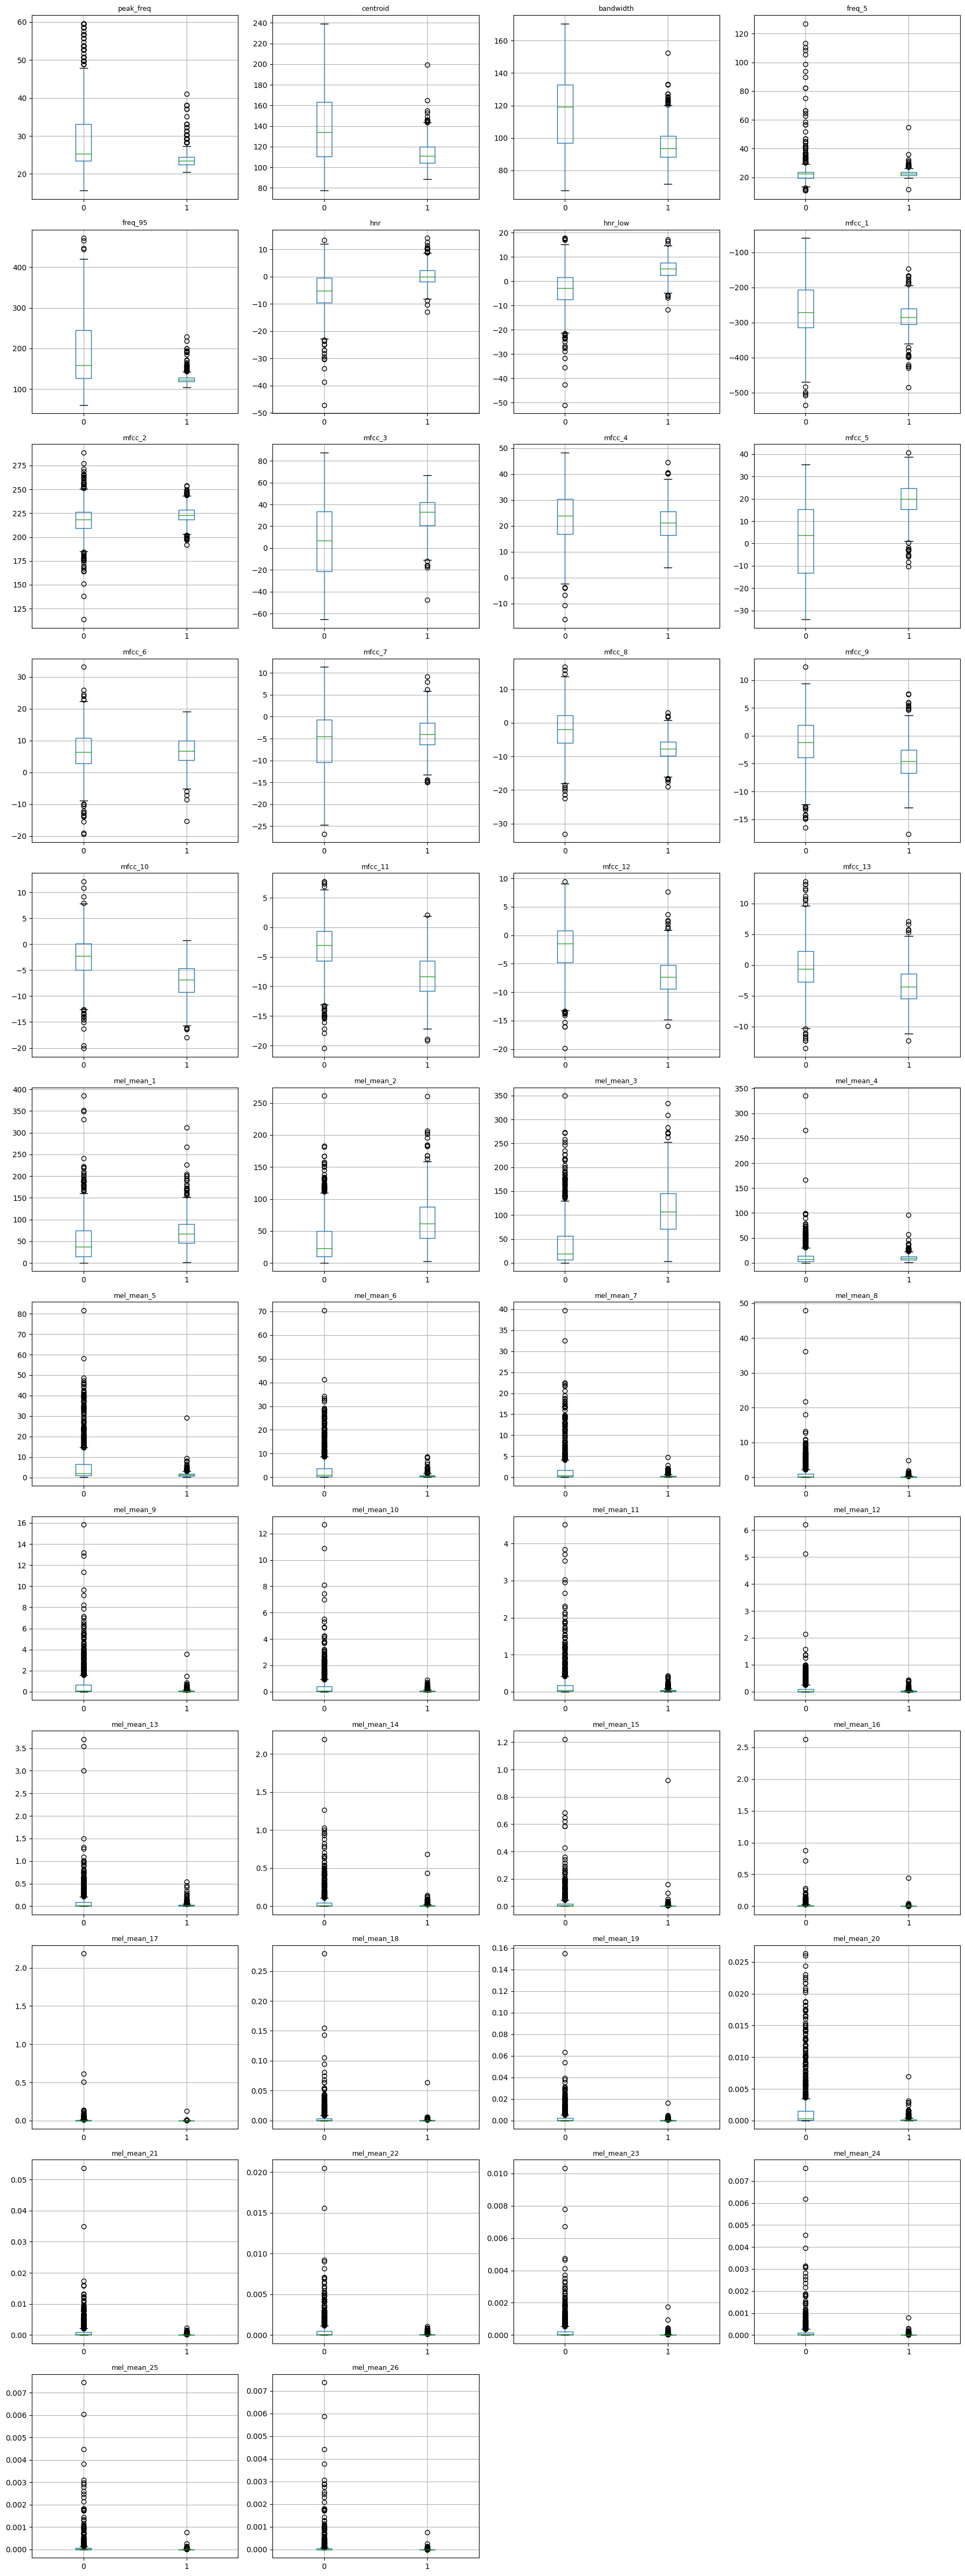

In [ ]:
import matplotlib.pyplot as plt

# List of feature columns (everything except the label)
feature_cols = df.columns.drop("label")

# Determine the layout of the figure
n_features = len(feature_cols)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 4 * n_rows)
)

axes = axes.flatten()

for i, feature in enumerate(feature_cols):

    df.boxplot(
        column=feature,
        by="label",
        ax=axes[i]
    )

    axes[i].set_title(feature, fontsize=9)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("")
plt.tight_layout()

plt.show()

### Statistical Testing
Because our data does not follow a uniform distribution, we will use a **Mann-Whitney U test**

In [ ]:
from scipy.stats import mannwhitneyu

In [ ]:
# run the test on every feature
results = []

feature_cols = df.columns.drop("label")

for feature in feature_cols:

    background = df[df["label"] == 0][feature]
    rumble = df[df["label"] == 1][feature]

    stat, p = mannwhitneyu(
        background,
        rumble,
        alternative="two-sided"
    )

    results.append({
        "Feature": feature,
        "U Statistic": stat,
        "P Value": p
    })

results = pd.DataFrame(results)

In [ ]:
# rank the features
results = results.sort_values("P Value")

results.head(20)

,Feature,U Statistic,P Value
22,mel_mean_3,82113.0,9.182701e-112
11,mfcc_5,91803.0,1.647725e-100
17,mfcc_11,439266.0,6.584825e-99
18,mfcc_12,436818.0,3.494081e-96
6,hnr_low,96763.0,5.534033e-95
16,mfcc_10,435520.0,9.384564e-95
14,mfcc_8,426698.0,2.497144e-85
4,freq_95,422692.0,3.026246e-81
2,bandwidth,409598.0,1.727508e-68
5,hnr,122937.0,1.894046e-68


In [ ]:
results["Significant"] = results["P Value"] < 0.05

results.head(20)

,Feature,U Statistic,P Value,Significant
22,mel_mean_3,82113.0,9.182701e-112,True
11,mfcc_5,91803.0,1.647725e-100,True
17,mfcc_11,439266.0,6.584825e-99,True
18,mfcc_12,436818.0,3.494081e-96,True
6,hnr_low,96763.0,5.534033e-95,True
16,mfcc_10,435520.0,9.384564e-95,True
14,mfcc_8,426698.0,2.497144e-85,True
4,freq_95,422692.0,3.026246e-81,True
2,bandwidth,409598.0,1.727508e-68,True
5,hnr,122937.0,1.894046e-68,True


In [ ]:
results["Significant"].value_counts()

Significant
True     45
False     1
Name: count, dtype: int64

In [ ]:
results[results["Significant"] == False]

,Feature,U Statistic,P Value,Significant
12,mfcc_6,257565.0,0.289578,False


To reduce the chance of luck in our analysis, we will use a **Benjamini–Hochberg false discovery rate (FDR)** to adjust the p-va;ues

In [ ]:
from statsmodels.stats.multitest import multipletests

results["Adjusted P"] = multipletests(
    results["P Value"],
    method="fdr_bh"
)[1]

results["Significant (FDR)"] = results["Adjusted P"] < 0.05

### Logistic Regression

In [ ]:
print(X_train.shape)
print(X_test.shape)

print(y_train.value_counts())
print(y_test.value_counts())

(1513, 46)
(379, 46)
label
0    956
1    557
Name: count, dtype: int64
label
0    231
1    148
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

model.fit(
    X_train_scaled,
    y_train
)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
y_pred = model.predict(X_test_scaled)

### Classifier Evaluation

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[194  37]
 [ 18 130]]


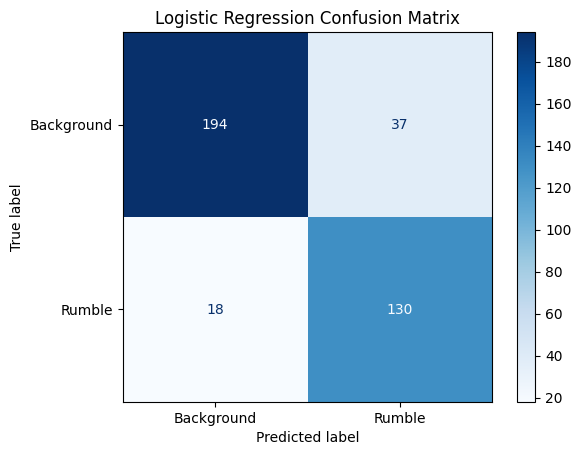

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Background", "Rumble"],
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.84      0.88       231
           1       0.78      0.88      0.83       148

    accuracy                           0.85       379
   macro avg       0.85      0.86      0.85       379
weighted avg       0.86      0.85      0.86       379



In [ ]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test_scaled)[:, 1]

auc = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC: {auc:.3f}")

ROC-AUC: 0.918


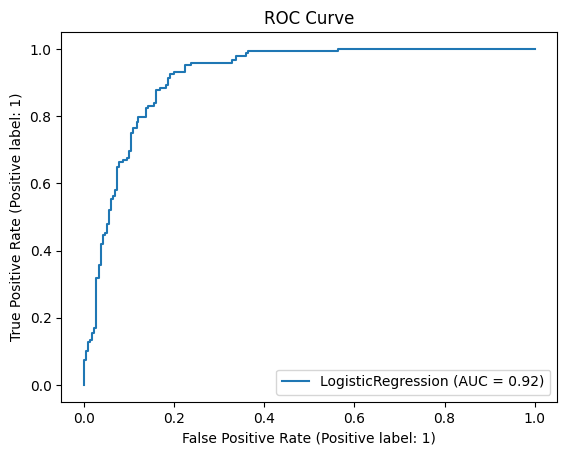

In [ ]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    model,
    X_test_scaled,
    y_test
)

plt.title("ROC Curve")
plt.show()

### Feature Importance from Logistic Regression

In [ ]:
import pandas as pd

coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_[0]
})

coefficients["Absolute Coefficient"] = (
    coefficients["Coefficient"].abs()
)

coefficients = coefficients.sort_values(
    "Absolute Coefficient",
    ascending=False
)

coefficients.head(10)

,Feature,Coefficient,Absolute Coefficient
6,hnr_low,2.127036,2.127036
5,hnr,-1.953674,1.953674
44,mel_mean_25,-1.376702,1.376702
45,mel_mean_26,-1.375281,1.375281
4,freq_95,-1.256140,1.256140
24,mel_mean_5,-1.069650,1.069650
9,mfcc_3,-1.055145,1.055145
0,peak_freq,-1.032318,1.032318
43,mel_mean_24,-0.762846,0.762846
11,mfcc_5,0.664176,0.664176


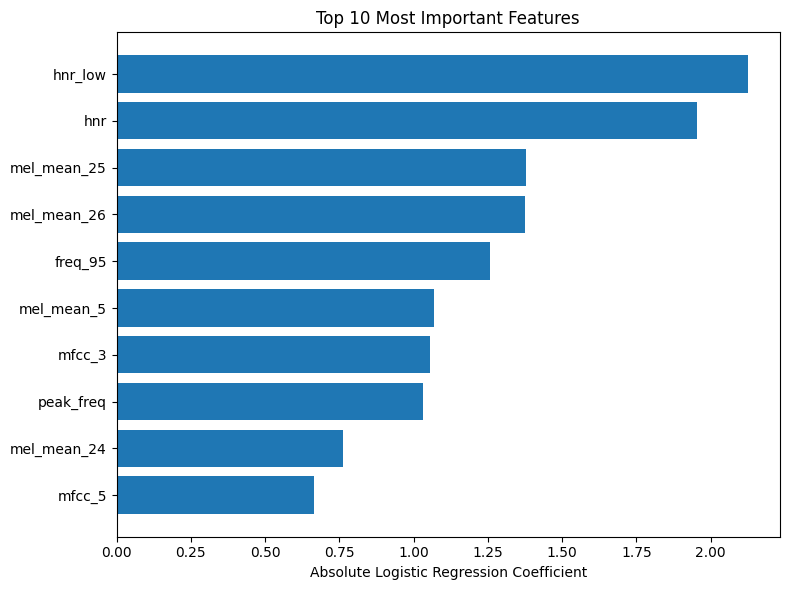

In [ ]:
import matplotlib.pyplot as plt

top10 = coefficients.head(10)

plt.figure(figsize=(8,6))

plt.barh(
    top10["Feature"],
    top10["Absolute Coefficient"]
)

plt.xlabel("Absolute Logistic Regression Coefficient")
plt.title("Top 10 Most Important Features")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [ ]:
feature_summary = coefficients.merge(
    results,
    on="Feature"
)

feature_summary = feature_summary.sort_values(
    "Absolute Coefficient",
    ascending=False
)

feature_summary.head(10)

,Feature,Coefficient,Absolute Coefficient,U Statistic,P Value,Significant,Adjusted P,Significant (FDR)
0,hnr_low,2.127036,2.127036,96763.0,5.534033e-95,True,5.091311e-94,True
1,hnr,-1.953674,1.953674,122937.0,1.894046e-68,True,8.712613e-68,True
2,mel_mean_25,-1.376702,1.376702,395000.0,1.326141e-55,True,5.083539e-55,True
3,mel_mean_26,-1.375281,1.375281,385826.0,3.296175e-48,True,7.980214e-48,True
4,freq_95,-1.256140,1.256140,422692.0,3.026246e-81,True,1.740091e-80,True
5,mel_mean_5,-1.069650,1.069650,364285.0,5.686702e-33,True,1.006109e-32,True
6,mfcc_3,-1.055145,1.055145,146371.0,1.943711e-48,True,4.967262e-48,True
7,peak_freq,-1.032318,1.032318,365390.0,3.505708e-34,True,6.450503e-34,True
8,mel_mean_24,-0.762846,0.762846,393025.0,5.760438e-54,True,1.892715e-53,True
9,mfcc_5,0.664176,0.664176,91803.0,1.647725e-100,True,3.789768e-99,True


### Cross Validation with Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

In [ ]:
rf_model.fit(
    X_train,
    y_train
)

RandomForestClassifier(n_estimators=200, random_state=42)

In [ ]:
rf_pred = rf_model.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    rf_pred
))

              precision    recall  f1-score   support

           0       0.89      0.85      0.87       231
           1       0.78      0.84      0.81       148

    accuracy                           0.85       379
   macro avg       0.84      0.85      0.84       379
weighted avg       0.85      0.85      0.85       379



### RandomForest Feature Importance

In [ ]:
import pandas as pd

rf_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    "Importance",
    ascending=False
)

rf_importance.head(15)

,Feature,Importance
6,hnr_low,0.079319
22,mel_mean_3,0.074482
18,mfcc_12,0.054224
5,hnr,0.052176
14,mfcc_8,0.047350
4,freq_95,0.047208
11,mfcc_5,0.042677
17,mfcc_11,0.039595
16,mfcc_10,0.036920
2,bandwidth,0.035312


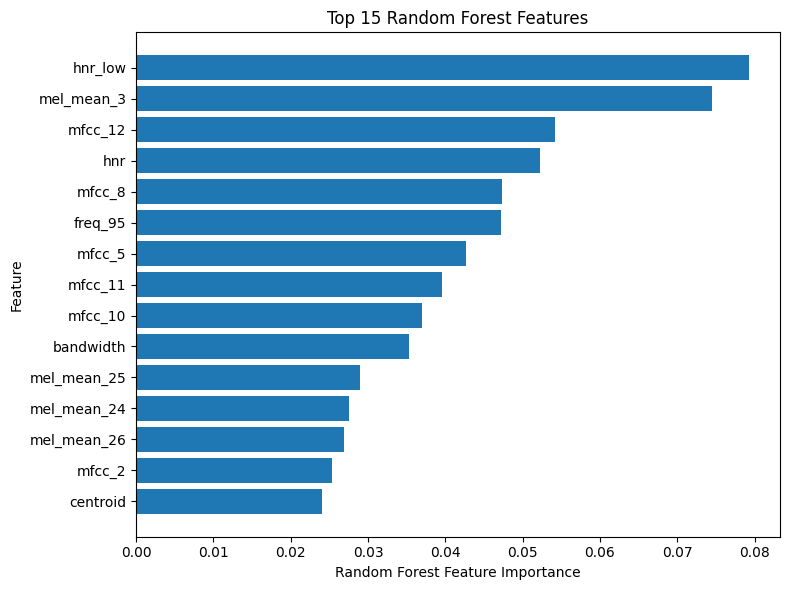

In [ ]:
import matplotlib.pyplot as plt

top15 = rf_importance.head(15)

plt.figure(figsize=(8,6))

plt.barh(
    top15["Feature"],
    top15["Importance"]
)

plt.xlabel("Random Forest Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Random Forest Features")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [ ]:
# Mann-Whitney U ranking
mw_rank = results.copy()

mw_rank = mw_rank.sort_values("P Value")

mw_rank["MW Rank"] = range(1, len(mw_rank)+1)

mw_rank = mw_rank[[
    "Feature",
    "MW Rank",
    "P Value"
]]

# Logistic Regression ranking
lr_rank = coefficients.copy()

lr_rank = lr_rank.sort_values(
    "Absolute Coefficient",
    ascending=False
)

lr_rank["LR Rank"] = range(1, len(lr_rank)+1)

lr_rank = lr_rank[[
    "Feature",
    "Coefficient",
    "Absolute Coefficient",
    "LR Rank"
]]

# Random Forest ranking
rf_rank = rf_importance.copy()

rf_rank = rf_rank.sort_values(
    "Importance",
    ascending=False
)

rf_rank["RF Rank"] = range(1, len(rf_rank)+1)

rf_rank = rf_rank[[
    "Feature",
    "Importance",
    "RF Rank"
]]

# merge
comparison = (
    mw_rank
    .merge(lr_rank, on="Feature")
    .merge(rf_rank, on="Feature")
)

# add overall ranking
comparison["Average Rank"] = (
    comparison["MW Rank"] +
    comparison["LR Rank"] +
    comparison["RF Rank"]
) / 3
comparison = comparison.sort_values("Average Rank")
comparison = comparison[[
    "Feature",
    "P Value",
    "Coefficient",
    "Importance",
    "MW Rank",
    "LR Rank",
    "RF Rank",
    "Average Rank"
]]

comparison.head(20)

,Feature,P Value,Coefficient,Importance,MW Rank,LR Rank,RF Rank,Average Rank
4,hnr_low,5.534033e-95,2.127036,0.079319,5,1,1,2.333333
9,hnr,1.894046e-68,-1.953674,0.052176,10,2,4,5.333333
1,mfcc_5,1.647725e-100,0.664176,0.042677,2,10,7,6.333333
7,freq_95,3.026246e-81,-1.256140,0.047208,8,5,6,6.333333
11,mel_mean_25,1.326141e-55,-1.376702,0.028909,12,3,11,8.666667
6,mfcc_8,2.497144e-85,-0.439603,0.047350,7,17,5,9.666667
5,mfcc_10,9.384564e-95,-0.454805,0.036920,6,15,9,10.000000
8,bandwidth,1.727508e-68,-0.480264,0.035312,9,12,10,10.333333
2,mfcc_11,6.584825e-99,-0.256278,0.039595,3,24,8,11.666667
13,mel_mean_24,5.760438e-54,-0.762846,0.027528,14,9,12,11.666667
